<a href="https://colab.research.google.com/github/Mao925/titanic/blob/main/titanic3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


X shape: (891, 26)
test shape: (418, 26)
Baseline CV scores: [0.83798883 0.82022472 0.82022472 0.82022472 0.84269663]
Baseline CV mean: 0.8282719226664993
Baseline CV std : 0.009967575842480647


,max_depth,min_samples_leaf,cv_mean,cv_std,diff_from_baseline,fold_scores
41,8,3,0.842860,0.011943,0.014588,"[0.8547486033519553, 0.8370786516853933, 0.831..."
33,7,3,0.840613,0.009372,0.012341,"[0.8547486033519553, 0.8314606741573034, 0.831..."
34,7,4,0.838372,0.007687,0.010100,"[0.8491620111731844, 0.8370786516853933, 0.825..."
44,8,6,0.837248,0.012963,0.008976,"[0.8491620111731844, 0.8426966292134831, 0.814..."
36,7,6,0.837242,0.012534,0.008970,"[0.8547486033519553, 0.8314606741573034, 0.820..."
42,8,4,0.836131,0.006739,0.007859,"[0.8435754189944135, 0.8370786516853933, 0.825..."
26,6,4,0.836125,0.009886,0.007853,"[0.8491620111731844, 0.8370786516853933, 0.820..."
35,7,5,0.836125,0.012175,0.007853,"[0.8491620111731844, 0.8426966292134831, 0.831..."
46,8,8,0.835007,0.012220,0.006735,"[0.8435754189944135, 0.8258426966292135, 0.820..."
40,8,2,0.834995,0.015931,0.006723,"[0.8547486033519553, 0.8314606741573034, 0.808..."


===== Best Params =====
max_depth: 8
min_samples_leaf: 3
CV mean: 0.8428598330299415
CV std : 0.011943424888331495
Baselineとの差分: 0.014587910363442202
fold scores: [0.8547486  0.83707865 0.83146067 0.83146067 0.85955056]


min_samples_leaf,2,3,4,5,6,7,8,10
max_depth,,,,,,,,
3,0.824907,0.824907,0.824907,0.824907,0.824907,0.826031,0.826031,0.822666
4,0.828272,0.827148,0.828272,0.829389,0.829389,0.830507,0.831630,0.827148
5,0.829396,0.833884,0.833884,0.832760,0.830513,0.831643,0.832760,0.832754
6,0.833877,0.833884,0.836125,0.832766,0.833877,0.833877,0.833884,0.833877
7,0.833877,0.840613,0.838372,0.836125,0.837242,0.832754,0.831636,0.832760
8,0.834995,0.842860,0.836131,0.832754,0.837248,0.832760,0.835007,0.834988


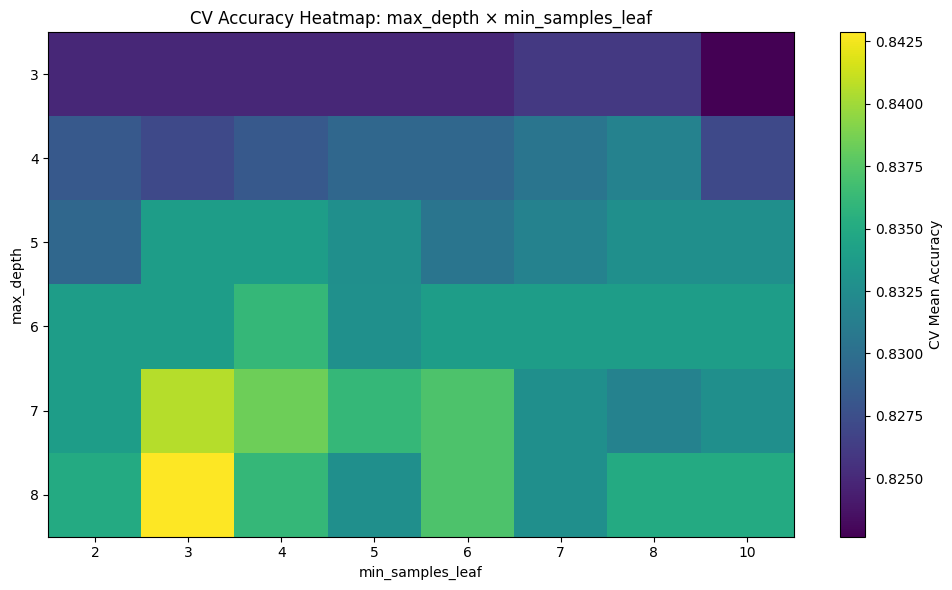

,model,max_depth,min_samples_leaf,cv_mean,cv_std,diff
0,baseline,4,4,0.828272,0.009968,0.000000
1,best_tuned,8,3,0.842860,0.011943,0.014588


作成完了: /content/submission_rf_tuned_depth_leaf.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


Survived
0    264
1    154
Name: count, dtype: int64


In [3]:
# ============================================
# Titanic RandomForest
# max_depth / min_samples_leaf 微調整CV分析
# ============================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

# ============================================
# 1. データ読み込み
# ============================================

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

# ============================================
# 2. 前処理・特徴量作成
# ============================================

def make_features(train, test):
    train = train.copy()
    test = test.copy()

    train["is_train"] = 1
    test["is_train"] = 0
    test["Survived"] = None

    df_all = pd.concat([train, test], axis=0)

    # ----------------------------
    # Title抽出
    # ----------------------------
    df_all["Title"] = df_all["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

    df_all["Title"] = df_all["Title"].replace(
        [
            "Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major",
            "Rev", "Sir", "Jonkheer", "Dona"
        ],
        "Rare"
    )

    df_all["Title"] = df_all["Title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    # ----------------------------
    # 欠損値補完
    # ----------------------------
    df_all["Embarked"] = df_all["Embarked"].fillna(df_all["Embarked"].mode()[0])
    df_all["Fare"] = df_all["Fare"].fillna(df_all["Fare"].median())

    df_all["Age"] = (
        df_all
        .groupby(["Sex", "Pclass"])["Age"]
        .transform(lambda x: x.fillna(x.median()))
    )

    # ----------------------------
    # 特徴量作成
    # ----------------------------
    df_all["FamilySize"] = df_all["SibSp"] + df_all["Parch"] + 1
    df_all["IsAlone"] = (df_all["FamilySize"] == 1).astype(int)
    df_all["IsChild"] = (df_all["Age"] < 16).astype(int)

    df_all["HasCabin"] = df_all["Cabin"].notnull().astype(int)
    df_all["Deck"] = df_all["Cabin"].str[0].fillna("Unknown")

    df_all["TicketGroupSize"] = df_all.groupby("Ticket")["Ticket"].transform("count")

    df_all["FarePerPerson"] = df_all["Fare"] / df_all["TicketGroupSize"]
    df_all["FarePerPerson"] = df_all["FarePerPerson"].fillna(
        df_all["FarePerPerson"].median()
    )

    # ----------------------------
    # 不要列削除
    # ----------------------------
    df_all = df_all.drop(
        ["PassengerId", "Name", "Cabin", "Ticket"],
        axis=1
    )

    # ----------------------------
    # ダミー化
    # ----------------------------
    df_all = pd.get_dummies(
        df_all,
        columns=["Sex", "Embarked", "Title", "Deck"],
        drop_first=True
    )

    # ----------------------------
    # train / test に戻す
    # ----------------------------
    train_processed = df_all[df_all["is_train"] == 1].drop("is_train", axis=1)
    test_processed = df_all[df_all["is_train"] == 0].drop(["is_train", "Survived"], axis=1)

    X = train_processed.drop("Survived", axis=1)
    y = train_processed["Survived"].astype(int)

    return X, y, test_processed


X, y, test_processed = make_features(train, test)

print("X shape:", X.shape)
print("test shape:", test_processed.shape)

# ============================================
# 3. CV設定
# ============================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================
# 4. ベースラインモデル
# ============================================

baseline_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

baseline_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

baseline_mean = baseline_scores.mean()
baseline_std = baseline_scores.std()

print("Baseline CV scores:", baseline_scores)
print("Baseline CV mean:", baseline_mean)
print("Baseline CV std :", baseline_std)

# ============================================
# 5. max_depth / min_samples_leaf のGridSearch
# ============================================

max_depth_list = [3, 4, 5, 6, 7, 8]
min_samples_leaf_list = [2, 3, 4, 5, 6, 7, 8, 10]

results = []

for max_depth in max_depth_list:
    for min_samples_leaf in min_samples_leaf_list:

        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )

        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="accuracy"
        )

        results.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "cv_mean": scores.mean(),
            "cv_std": scores.std(),
            "diff_from_baseline": scores.mean() - baseline_mean,
            "fold_scores": scores
        })

result_df = pd.DataFrame(results)

# ============================================
# 6. 結果確認
# ============================================

result_df_sorted = result_df.sort_values(
    ["cv_mean", "cv_std"],
    ascending=[False, True]
)

display(result_df_sorted)

print("===== Best Params =====")
best_row = result_df_sorted.iloc[0]

print("max_depth:", best_row["max_depth"])
print("min_samples_leaf:", best_row["min_samples_leaf"])
print("CV mean:", best_row["cv_mean"])
print("CV std :", best_row["cv_std"])
print("Baselineとの差分:", best_row["diff_from_baseline"])
print("fold scores:", best_row["fold_scores"])

# ============================================
# 7. ピボットテーブルで見やすく表示
# ============================================

pivot_mean = result_df.pivot(
    index="max_depth",
    columns="min_samples_leaf",
    values="cv_mean"
)

display(pivot_mean)

plt.figure(figsize=(10, 6))
plt.imshow(pivot_mean, aspect="auto")
plt.colorbar(label="CV Mean Accuracy")

plt.xticks(
    ticks=range(len(pivot_mean.columns)),
    labels=pivot_mean.columns
)

plt.yticks(
    ticks=range(len(pivot_mean.index)),
    labels=pivot_mean.index
)

plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.title("CV Accuracy Heatmap: max_depth × min_samples_leaf")
plt.tight_layout()
plt.show()

# ============================================
# 8. ベースライン vs ベストモデル比較
# ============================================

best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=int(best_row["max_depth"]),
    min_samples_leaf=int(best_row["min_samples_leaf"]),
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

best_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

comparison_df = pd.DataFrame({
    "model": ["baseline", "best_tuned"],
    "max_depth": [4, int(best_row["max_depth"])],
    "min_samples_leaf": [4, int(best_row["min_samples_leaf"])],
    "cv_mean": [baseline_mean, best_scores.mean()],
    "cv_std": [baseline_std, best_scores.std()],
    "diff": [0, best_scores.mean() - baseline_mean]
})

display(comparison_df)

# ============================================
# 9. Kaggle提出用CSV作成
# ============================================

best_model.fit(X, y)

pred = best_model.predict(test_processed)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"].astype(int),
    "Survived": pred.astype(int)
})

submission.to_csv("/content/submission_rf_tuned_depth_leaf.csv", index=False)

print("作成完了: /content/submission_rf_tuned_depth_leaf.csv")
display(submission.head())
print(submission["Survived"].value_counts())

In [4]:
# ============================================
# submission.csv 作成
# max_depth=4, min_samples_leaf=8
# ============================================

rf_conservative_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=8,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_conservative_tuned.fit(X, y)

pred = rf_conservative_tuned.predict(test_processed)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"].astype(int),
    "Survived": pred.astype(int)
})

submission.to_csv("/content/submission_rf_depth4_leaf8.csv", index=False)

print("作成完了: /content/submission_rf_depth4_leaf8.csv")
display(submission.head())
print(submission["Survived"].value_counts())

作成完了: /content/submission_rf_depth4_leaf8.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Survived
0    260
1    158
Name: count, dtype: int64


In [5]:
# ============================================
# submission.csv 作成
# max_depth=3, min_samples_leaf=8
# ============================================

rf_depth3_leaf8 = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=8,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_depth3_leaf8.fit(X, y)

pred = rf_depth3_leaf8.predict(test_processed)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"].astype(int),
    "Survived": pred.astype(int)
})

submission.to_csv("/content/submission_rf_depth3_leaf8.csv", index=False)

print("作成完了: /content/submission_rf_depth3_leaf8.csv")
display(submission.head())
print(submission["Survived"].value_counts())

作成完了: /content/submission_rf_depth3_leaf8.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Survived
0    265
1    153
Name: count, dtype: int64


In [6]:
# ============================================
# submission.csv 作成
# max_depth=3, min_samples_leaf=7
# ============================================

rf_depth3_leaf7 = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=7,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_depth3_leaf7.fit(X, y)

pred = rf_depth3_leaf7.predict(test_processed)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"].astype(int),
    "Survived": pred.astype(int)
})

submission.to_csv("/content/submission_rf_depth3_leaf7.csv", index=False)

print("作成完了: /content/submission_rf_depth3_leaf7.csv")
display(submission.head())
print(submission["Survived"].value_counts())

作成完了: /content/submission_rf_depth3_leaf7.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Survived
0    265
1    153
Name: count, dtype: int64


In [7]:
# ============================================
# submission.csv 作成
# max_depth=3, min_samples_leaf=7
# ============================================

rf_depth3_leaf7 = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=7,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_depth3_leaf7.fit(X, y)

pred = rf_depth3_leaf7.predict(test_processed)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"].astype(int),
    "Survived": pred.astype(int)
})

submission.to_csv("/content/submission_rf_depth3_leaf7.csv", index=False)

print("作成完了: /content/submission_rf_depth3_leaf7.csv")
display(submission.head())
print(submission["Survived"].value_counts())

作成完了: /content/submission_rf_depth3_leaf7.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Survived
0    265
1    153
Name: count, dtype: int64


In [8]:
# ============================================
# submission.csv 作成
# max_depth=2, min_samples_leaf=8
# ============================================

rf_depth2_leaf8 = RandomForestClassifier(
    n_estimators=300,
    max_depth=2,
    min_samples_leaf=8,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_depth2_leaf8.fit(X, y)

pred = rf_depth2_leaf8.predict(test_processed)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"].astype(int),
    "Survived": pred.astype(int)
})

submission.to_csv("/content/submission_rf_depth2_leaf8.csv", index=False)

print("作成完了: /content/submission_rf_depth2_leaf8.csv")
display(submission.head())
print(submission["Survived"].value_counts())

作成完了: /content/submission_rf_depth2_leaf8.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Survived
0    267
1    151
Name: count, dtype: int64


In [9]:
# ============================================
# submission.csv 作成
# max_depth=3, min_samples_leaf=6 / 9
# ============================================

configs = [
    {"name": "depth3_leaf6", "max_depth": 3, "min_samples_leaf": 6},
    {"name": "depth3_leaf9", "max_depth": 3, "min_samples_leaf": 9},
]

for cfg in configs:
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X, y)

    pred = model.predict(test_processed)

    submission = pd.DataFrame({
        "PassengerId": test["PassengerId"].astype(int),
        "Survived": pred.astype(int)
    })

    output_path = f"/content/submission_rf_{cfg['name']}.csv"
    submission.to_csv(output_path, index=False)

    print(f"作成完了: {output_path}")
    print(submission["Survived"].value_counts())
    display(submission.head())
    print("-" * 50)

作成完了: /content/submission_rf_depth3_leaf6.csv
Survived
0    266
1    152
Name: count, dtype: int64


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


--------------------------------------------------
作成完了: /content/submission_rf_depth3_leaf9.csv
Survived
0    266
1    152
Name: count, dtype: int64


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


--------------------------------------------------
